# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Castaneda, Joaquin
- _Student No._: 2024-09743
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

![problem2.1](problem_2.1.png)

![problem2.2](problem_2.2.png)

"Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?"

The "bad" formula for $x_+$ suffers from catastrophic cancellation because it subtracts two nearly equal large numbers, $-b$ and $\sqrt{b^2-4ac}$, causing significant digits to be lost. The "good" formula avoids this subtraction by using the relationship $x_+x_-=\frac{c}{a}$, so $x_+=\frac{c/a}{x_-}$, which gives a more accurate result. The difference between the obtained values therefore comes from floating-point round-off error and loss of significant digits during the subtraction.

"In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied?"



---
## Section 1: Report

### Report figure

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` (for more info, check bottomost cell under Section 3). Make sure the figure has complete elements.

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussion here. This is not related to Problem 1. Discuss your key results with ~150 words.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
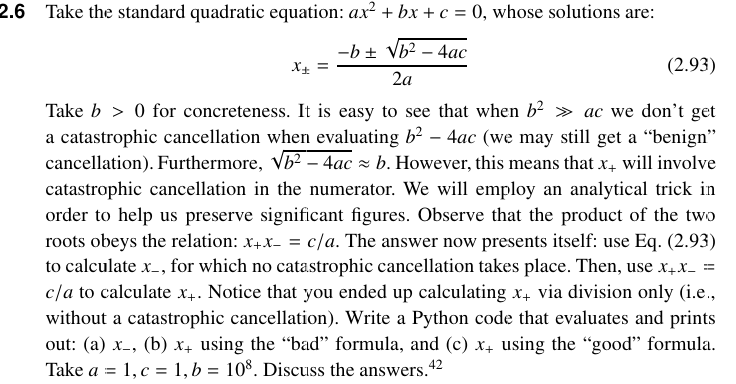

In [2]:
from math import sqrt

# coefficients
a, b, c = 1, 10**8, 1

# (a) x_minus using the standard formula
x_minus = (-b - sqrt(b**2 - 4*a*c)) / (2*a)

# (b) x_plus using the bad formula
x_plus_bad = (-b + sqrt(b**2 - 4*a*c)) / (2*a)

# (c) x_+ using the "good" formula
x_plus_good = (c / a) / x_minus

print("x_- =", x_minus)
print("x_+ (bad)  =", x_plus_bad)
print("x_+ (good) =", x_plus_good)

x_- = -100000000.0
x_+ (bad)  = -7.450580596923828e-09
x_+ (good) = -1e-08


#### Problem 1 code summary

This script compares the standard and numerically stable methods for calculating the roots of a quadratic equation. The stable method computes $x_+$ by using $x_+ = \frac{c/a}{x_-}$ so we can avoid catastrophic cancellation caused by subtracting numbers that are nearly equal.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

Catastrophic cancellation occurs for large positive x.

We can rewrite the original function to avoid catastrophic cancellation by finding the conjugate.

$\sqrt(x^2 + x) - x$

$\left(\sqrt{x^2 + x} - x\right) \cdot \frac{\sqrt{x^2 + x} + x}{\sqrt{x^2 + x} + x}$

$\frac{x}{\sqrt(x^2 + x) + x}$

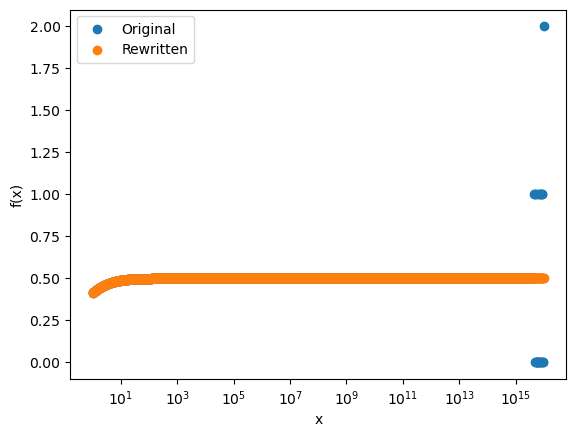

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# let's use logspace so that we can immediately see behaviour for very small / very large
x = np.logspace(0, 16, 1000)

# The original function f1
def f_orig(x):
    return np.sqrt(x**2 + x) - x

# The rewritten function f2
def f_rewritten(x):
    return x / (np.sqrt(x**2 + x) + x)

plt.scatter(x, f_orig(x), label="Original")
plt.scatter(x, f_rewritten(x), label="Rewritten")

plt.savefig('problem_2.1.png', dpi=100, bbox_inches='tight')

plt.xscale("log")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

#### Code Summary

This script compares the original and rewritten forms of \(f(x) = \sqrt{x^2+x}-x\) for large values of \(x\). The rewritten version avoids subtracting two nearly equal numbers, which reduces the loss of precision caused by catastrophic cancellation, while the log scale makes the behavior at large \(x\) easier to see.


#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



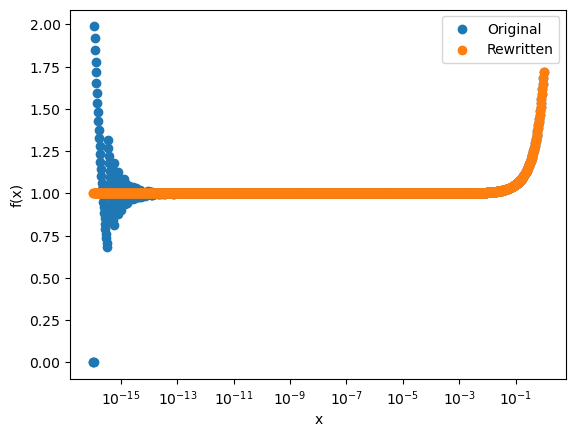

In [47]:
import numpy as np
import matplotlib.pyplot as plt

x = np.logspace(-16, 0, 1000)

# Original function
def f_orig(x):
    return (np.exp(x) - 1) / x

# Rewritten function
def f_rewritten(x):
    return np.expm1(x) / x

plt.scatter(x, f_orig(x), label="Original")
plt.scatter(x, f_rewritten(x), label="Rewritten")

plt.savefig('problem_2.2.png', dpi=300, bbox_inches='tight')

plt.xscale("log")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

#### Problem 2 code summary

This script compares the original and rewritten ways of evaluating $f(x) = \frac{e^x - 1}{x}$ for small values of $x$. The rewritten version uses `np.expm1(x)` to avoid the loss of precision from subtracting two nearly equal numbers, while the log scale helps show the difference between the two methods at small $x$.


---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


**End of Exercise 2.**